# Congestion Pricing and NYC Drivers

On 5 January 2025 New York started charging a toll to enter Manhattan below 60th Street. This notebook measures how the toll changed yellow taxi and high volume for-hire vehicle (Uber/Lyft) trips and driver earnings.

Run it from top to bottom. The functions it calls live in `scripts/`. Setup steps are in `README.md`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import functions as F

from scripts import (clean, config, download, explore, external, plots,
                     spark_io, zones)

# Every figure uses the shared style
plt.style.use(config.STYLE_FILE)

months = config.months_to_process()
print(f"QUICK_RUN = {config.quick_run()}: {len(months)} months, "
      f"{months[0]} to {months[-1]}")

QUICK_RUN = False: 36 months, (2023, 1) to (2025, 12)


## 1. Download the data

Everything is saved to `data/raw/`. Each download is skipped if its file is already there, so running this section again is quick. The functions are in `scripts/download.py`.

### 1.1 TLC trip data

One parquet file per month for yellow taxis and high volume for-hire vehicle trips (mostly Uber and Lyft), from the [TLC trip record page](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page). The full run downloads 72 files (about 20 GB). The table shows rows × columns of every raw file.

In [2]:
tlc_files = download.download_tlc(months)
download.split_large_row_groups(tlc_files)

# Rows x columns of every raw TLC file
tlc_shapes = download.parquet_shapes(tlc_files)
tlc_shapes["service"] = tlc_shapes["file"].str.split("_").str[0]

# Totals per service, for Table 1 in the report
plots.flat(tlc_shapes.groupby("service").agg(
    files=("file", "count"), rows=("rows", "sum"),
    min_columns=("columns", "min"), max_columns=("columns", "max"),
    size_gb=("size_mb", lambda mb: round(mb.sum() / 1000, 1))))

TLC: 72 files, 72 already downloaded, 0 to download


Service,Files,Rows,Fewest columns,Most columns,Size (GB)
High Volume For-Hire Vehicle,36,715550152,24,25,17.3
Yellow Taxi,36,128202548,19,20,2.2


### 1.2 External datasets

Four datasets add the tolled area, the zone map, background speeds and weather to the trip data. The table under the code cell gives rows × columns for each.

| Dataset | Source | Used for | Coverage |
|---|---|---|---|
| Taxi zone lookup and shapefile | [TLC](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) | Zone names, boroughs and shapes; finding the ring of zones around the CBD (Section 2.1) | 265 zone IDs, 263 with a shape |
| CBD taxi zones | [MTA](https://data.ny.gov/d/yfdc-w5jh) | Which zones are inside the tolled area | 38 zones |
| CBD taxi/FHV speeds | [MTA](https://data.ny.gov/d/6p29-6xqn) | Monthly average speed in the CBD, the CBD-adjacent area and the rest of the city, for one line of background | October 2019 – August 2025, 213 rows |
| Daily weather, Central Park | NOAA GHCN-Daily, station `USW00094728` | Rain, snow and temperature controls in the models | Every day of 2023–2025, in mm and °C |

In [3]:
external_files = download.download_external()

# Rows x columns of each raw external dataset
plots.flat(download.external_shapes(external_files))

Dataset,Files,Rows,Columns
Zone lookup,1,265,4
CBD zones,1,38,2
CBD speeds,1,213,3
Weather,1,1096,7
Zone shapefile,1,263,7


## 2. Prepare the external data

The external datasets are turned into tables that join onto the trips by zone, date or time band: zone labels, weather and holidays.

### 2.1 Zone labels

The analysis compares trips that touch the tolled area (`cbd`) with trips that don't (`control`). Zones just outside the CBD fit neither group. Riders can walk out of the CBD to avoid the toll and drivers can wait at its edge, so these zones may *gain* trips because of the toll. Counting them as control would make the toll's effect look bigger than it is, so they get their own group, the `ring`.

`zone_group_fine` splits the ring and the control group further, for robustness checks:

- **Ring:** zones across the street from the CBD, where a rider can simply walk over the boundary, are kept apart from zones across the river, which are reached by bridge or tunnel.
- **Control:** the control zones nearest the ring are kept apart to test whether the ring is wide enough. If they react to the toll the way the ring does, the ring should be wider (the buffer-band check in Step 6).

The first table counts the zones in each group; the second lists the 19 ring zones.

In [4]:
zone_labels = zones.build_zone_labels()
print(f"Zone labels: {zone_labels.shape[0]} rows x {zone_labels.shape[1]} "
      f"columns, saved to {zones.LABELS_FILE.name}")
display(plots.flat(pd.crosstab(  # noqa: F821
    zone_labels["zone_group_fine"], zone_labels["zone_group"], margins=True,
    margins_name="Total")))

# The ring zones, nearest first
plots.flat(zone_labels[zone_labels["zone_group"] == "ring"]
           .sort_values("distance_to_cbd_ft")
           [["LocationID", "Borough", "Zone", "distance_to_cbd_ft",
             "zone_group_fine"]])

Zone labels: 265 rows x 8 columns, saved to zone_labels.csv


Fine zone group,CBD,Control,Ring,Total
CBD,38,0,0,38
"Control, far",0,190,0,190
"Control, near",0,16,0,16
"Ring, across water",0,0,13,13
"Ring, adjacent",0,0,6,6
Total,38,206,19,263


Zone ID,Borough,Zone,Distance to CBD (ft),Fine zone group
141,Manhattan,Lenox Hill West,0,"Ring, adjacent"
43,Manhattan,Central Park,0,"Ring, adjacent"
237,Manhattan,Upper East Side South,0,"Ring, adjacent"
143,Manhattan,Lincoln Square West,0,"Ring, adjacent"
142,Manhattan,Lincoln Square East,0,"Ring, adjacent"
140,Manhattan,Lenox Hill East,0,"Ring, adjacent"
202,Manhattan,Roosevelt Island,908,"Ring, across water"
145,Queens,Long Island City/Hunters Point,1334,"Ring, across water"
34,Brooklyn,Brooklyn Navy Yard,1374,"Ring, across water"
33,Brooklyn,Brooklyn Heights,1416,"Ring, across water"


In [5]:
# Zone IDs that share a name. The check inside shared_names()
# also confirms that no two zones share a shape, so maps and
# joins keyed on LocationID cannot double-count them.
plots.flat(zones.shared_names(), merge=["zone", "borough"])

### 2.2 Weather and public holidays

Snow, heavy rain and holidays change how many people take a taxi, so weather and holidays are controls in the Section 6 models. Without them, a bad winter after the toll started could look like part of the toll's effect.

- **Weather:** the Central Park station stands in for the whole city, since rain and snow reach every zone on the same day. `rain_mm` is NOAA's total precipitation, so it includes melted snow. The table below shows the range of each column.
- **Holidays:** they are typed out in `external.HOLIDAYS` rather than taken from a package, so the pinned requirements don't grow.

In [6]:
weather = external.load_weather()
print(f"Weather: {weather.shape[0]:,} rows x "
      f"{weather.shape[1]} columns, "
      f"{weather['date'].min():%Y-%m-%d} to "
      f"{weather['date'].max():%Y-%m-%d}")
print(f"Public holidays: {len(external.HOLIDAYS)} dates")
plots.flat(weather.drop(columns="date").describe().round(1)
           .rename_axis("statistic"))

Weather: 1,096 rows x 6 columns, 2023-01-01 to 2025-12-31
Public holidays: 35 dates


Statistic,Rain (mm),Snow (mm),Snow depth (mm),Max temperature (°C),Min temperature (°C)
Count,1096.0,1096.0,1096.0,1096.0,1096.0
Mean,3.4,0.7,1.6,17.9,10.1
Standard deviation,9.6,5.7,8.6,9.5,8.5
Min,0.0,0.0,0.0,-7.1,-16.0
25%,0.0,0.0,0.0,10.0,3.3
50%,0.0,0.0,0.0,17.8,10.0
75%,1.4,0.0,0.0,26.1,17.8
Max,139.2,81.0,102.0,37.2,27.2


## 3. Clean the taxi data

The functions are in `scripts/clean.py`. Every check and outlier cut-off runs on the full data: the cut-offs sit in thin tails (Section 3.5), and some recording problems are concentrated in one vendor's Flex Fare trips in 2025 (Section 3.3), so a sample could miss them.

### 3.1 Read the raw files

`spark_io.read_service` reads every month, keeps only the columns used below and casts them to one schema, so the months can be stacked. The step table in Section 3.7 gives the rows × columns before and after.

In [ ]:
spark = spark_io.get_spark()
spark.sparkContext.setLogLevel("ERROR")

# Raw trips with the kept columns, plus trip_seconds, trip_hours, speed_mph
raw = {service: clean.add_trip_time(
           spark_io.read_service(spark, service, months), service)
       for service in config.SERVICES}

# Raw column count for the step table (it differs between years)
raw_columns = {}
for service in config.SERVICES:
    counts = tlc_shapes.loc[tlc_shapes["service"] == service, "columns"]
    low, high = counts.min(), counts.max()
    raw_columns[service] = str(low) if low == high else f"{low}-{high}"

### 3.2 Nulls

Nulls in every kept column, counted on the full data by month, vendor and (for yellow) payment type. The tables add the months up by year and leave out columns with no nulls.

In [8]:
nulls = {service: clean.null_counts(raw[service], service)
         for service in config.SERVICES}

# Yellow: nulls by year, vendor and payment type
plots.flat(clean.nulls_by_year(nulls["yellow"], ["VendorID", "payment_type"]),
           merge=["year", "VendorID"])

In [9]:
# High Volume FHV: nulls by year and company
plots.flat(clean.nulls_by_year(nulls["fhvhv"], ["hvfhs_license_num"]),
           merge=["year"])

In [10]:
# The yellow table month by month: the four columns are null on every
# Flex Fare row and on no other row, so no row has only some of them null
yellow_nulls = nulls["yellow"]
is_flex = yellow_nulls["payment_type"] == clean.FLEX_FARE
for column in ["passenger_count", "RatecodeID", "congestion_surcharge",
               "airport_fee"]:
    assert (yellow_nulls[column]
            == yellow_nulls["rows"].where(is_flex, 0)).all(), column
print(f"Yellow: the four columns are null on exactly the Flex Fare rows, in "
      f"all {yellow_nulls['file_month'].nunique()} months")

Yellow: the four columns are null on exactly the Flex Fare rows, in all 36 months


**What the null counts show:**

- **Yellow:** only `passenger_count`, `RatecodeID`, `congestion_surcharge` and `airport_fee` ever have nulls, and in every month they're null on exactly the `payment_type` 0 rows (the check above). The data dictionary lists these as Flex Fare trips, a fixed price agreed upfront. `cbd_congestion_fee` is null on every row before 2025, when it was introduced, and on none after.
- **High volume for-hire vehicle:** no nulls, apart from `cbd_congestion_fee` before 2025.

**Decisions:** no row is dropped because of nulls.

- `cbd_congestion_fee` before 2025 stays null. The fee didn't exist, and trips are placed in or out of the zone with the MTA zone list instead.
- The Flex Fare rows are kept. They are real trips, and their share of yellow trips grows fast (Section 3.8), so dropping them would make yellow trips look like they fell after the toll. Their four columns stay null: `passenger_count` isn't used, the `RatecodeID` 99 rule keeps a null rate code (Section 3.7), and the Vendor 1 `extra` rule counts a null fee as 0 (Section 3.4).

### 3.3 Zero and negative yellow fares

Zero and negative `fare_amount` by year, vendor and payment type, for groups with more than 1,000 such rows. A negative fare counts as a reversal when another row has the same vendor, pickup and drop-off times and zones, and the same fare with a positive sign, so the two rows cancel.

In [11]:
# Zero and negative fares by year, vendor and payment type
fares = clean.fare_signs(raw["yellow"])
plots.flat(fares[fares["negative"] + fares["zero"] > 1000],
           merge=["year", "VendorID"])

**What the table shows:**

- **Most negative fares outside Flex Fare are reversals.** Vendor 2's no-charge (3) and dispute (4) payments are about 50% negative, and 88–92% of those negative rows cancel a positive row. So do 88–89% of its negative cash (2) fares. Vendor 1 has almost no negative fares.
- **Vendor 2's Flex Fare trips (payment type 0) are different.** Their negative share jumps from 0.86% in 2023 and 3.94% in 2024 to 20.45% in 2025 (2,047,089 rows), and none of them cancels a positive row.

**Decision:** step 5 of the cleaning (Section 3.7) removes zero and negative fares, except on Flex Fare trips. Those aren't reversals, so they are **kept for trip counts, but their revenue is unknown** (Section 3.8). Dropping them would remove about 4% of 2025 yellow rows.

### 3.4 Yellow `extra`

Revenue for yellow taxis is `fare_amount` plus the part of `extra` that goes to the driver. The TLC fare rules have three such surcharges: $1 overnight (8pm–6am), $2.50 on weekday rush hours (4–8pm) and $5 on LaGuardia trips and JFK flat-fare trips. So the driver's part of `extra` should be 0, 1, 2.50, 5, 6 or 7.50. The data dictionary only calls `extra` "miscellaneous extras and surcharges", so the table below gives its values on more than 1% of a vendor's trips in a year.

In [ ]:
# Most common extra values: share of each vendor-year's trips, in %
extra = clean.extra_values(raw["yellow"])
extra_shares = (extra.groupby(["VendorID", "year", "extra"])["count"].sum()
                / extra.groupby(["VendorID", "year"])["count"].sum() * 100)
plots.flat(extra_shares[extra_shares > 1].round(1).rename("pct")
           .reset_index().pivot(index=["VendorID", "extra"], columns="year",
                                values="pct").fillna(0),
           merge=["VendorID"])

**What the table shows:**

- **Vendor 2 (Curb)**, about three quarters of yellow trips (next table): `extra` is 0, 1, 2.50, 5 or 6 on at least 97% of its trips every year, so it holds only the driver surcharges.
- **Vendor 1 (Creative Mobile Technologies)**: the most common non-zero values are 2.50, 3.50 and 5.00 in 2023–2024, and 3.25, 4.25 and 5.75 in 2025. These are the driver surcharges plus the $2.50 congestion surcharge and, from 2025, the $0.75 CBD fee (9.25 also adds the $1.75 airport fee). Vendor 1 puts those city and MTA charges into `extra` **as well as** in their own columns.

**Rule:** for Vendor 1, subtract `congestion_surcharge`, `airport_fee` and `cbd_congestion_fee` from `extra`. If that doesn't leave a valid driver surcharge, try again without subtracting the CBD fee, for rows where Vendor 1 left the CBD fee out of `extra`. Other vendors' `extra` is used as it is. If no valid surcharge is found, the trip's revenue is unknown (null) but the trip is kept. The next table counts how many trips the rule matches, with and without the CBD fee fallback.

In [13]:
# How many trips get a valid driver surcharge, by vendor and year
plots.flat(clean.extra_rule_coverage(raw["yellow"]))

Vendor,Year,Rows,With a surcharge,Share with a surcharge
1,2023,10037714,10022656,0.998500
1,2024,9715918,9699529,0.998313
1,2025,9586873,9573071,0.998560
2,2023,28263844,28069946,0.993140
2,2024,31451503,31145278,0.990264
2,2025,38575846,38155557,0.989105
6,2023,8668,8668,1.000000
6,2024,2069,1656,0.800387
6,2025,23982,23982,1.000000
7,2024,230,230,1.000000


The rule finds a valid driver surcharge on over 99.8% of Vendor 1 trips in every year, and on about 99% of Vendor 2 trips. Without the CBD fee fallback, Vendor 1's 2025 share falls to 88.85%, so on about 11% of its 2025 trips the CBD fee was left out of `extra`.

### 3.5 Distributions and outlier cut-offs

Quantiles of trip length (minutes), distance (miles), average speed (mph) and money (`fare_amount` for yellow, `driver_pay` for high volume for-hire vehicle) on every raw trip with a positive time and distance. They are read off full-data histograms with fine bins (0.1 minute, 0.05 mile, 0.1 mph, $0.25), so they are accurate to one bin; values below the first bin show as, for example, `<0.05`. The plots below count every raw trip in coarser bins, with values past either edge added to the end bins so the outliers stay visible.

In [ ]:
quantiles = {s: clean.distribution_quantiles(raw[s], s)
             for s in config.SERVICES}
plots.flat(pd.concat(quantiles, axis=1))

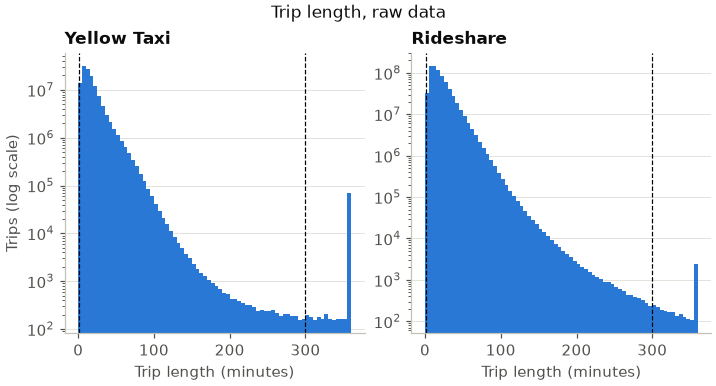

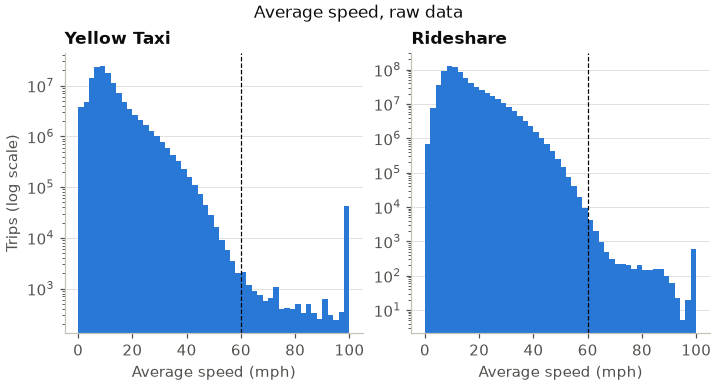

In [15]:
# Full-data histograms of trip length and average speed. Dashed lines are
# the cut-offs in clean.py.
minutes = {s: clean.histogram(raw[s].withColumn("trip_minutes",
                                                F.col("trip_seconds") / 60),
                              "trip_minutes", 0, 360, 5)
           for s in config.SERVICES}
plots.histograms(minutes, [clean.MIN_TRIP_MINUTES, clean.MAX_TRIP_MINUTES],
                 "Trip length (minutes)", "Trip length, raw data")
plt.show()

speeds = {s: clean.histogram(raw[s], "speed_mph", 0, 100, 2)
          for s in config.SERVICES}
plots.histograms(speeds, [clean.MAX_SPEED_MPH], "Average speed (mph)",
                 "Average speed, raw data")
plt.show()

**Cut-offs** (constants at the top of `scripts/clean.py`):

- **Trip length:** at least 1 minute and at most 5 hours. Trips under 1 minute are fewer than 1% of yellow and 0.1% of high volume for-hire vehicle trips (the 1st percentile for yellow and the 0.1th percentile for high volume for-hire vehicle are both 2 minutes). The 99.9th percentile is under 2 hours for both services. Past about 4 hours the yellow histogram flattens into a tail of about 200 trips per 5-minute bin, which looks like meters left running, and the last bin holds every trip of 6 hours or more.
- **Distance:** at most 100 miles. The 99.9th percentile is about 30 miles for yellow and 54 miles for high volume for-hire vehicle.
- **Average speed:** at most 60 mph over the whole trip. The 99.9th percentile is under 50 mph for both services. Above 60 mph the histograms thin out, apart from a pile-up of impossible values of 100 mph or more in the last bin.
- **Money:** `fare_amount` (yellow) or `driver_pay` (high volume for-hire vehicle) at most $500. The 99.9th percentile is about $140–150 for both.

Together the four cut-offs remove 0.29% of yellow rows and 0.02% of high volume for-hire vehicle rows (Section 3.7), so the summary medians don't depend on exactly where the lines sit.

### 3.6 Time bands

The CBD fee on 2025 trips, and the share of trips in each pickup hour on weekdays and weekends. The toll for cars has a peak rate on weekdays from 5am to 9pm (9am to 9pm on weekends) and a lower overnight rate.

In [ ]:
# CBD fee values on 2025 trips, and how many pickup hours each appears in
display(plots.flat(pd.concat({s: clean.cbd_fee_values(raw[s], s)  # noqa: F821
                              for s in config.SERVICES}, names=["service"]),
                   merge=["service"]))

hourly = {s: clean.hourly_counts(raw[s], s) for s in config.SERVICES}
plots.hourly_shares(hourly, "Trips by pickup hour")
plt.show()

The fee has one main value per service in 2025, **$0.75 on yellow trips** and **$1.50 on high volume for-hire vehicle trips**, and it appears in all 24 pickup hours. Apart from 0 (no fee) and -$0.75 on 1% of yellow trips, every other value is on fewer than 200 trips. The fee itself therefore gives no reason to split the day. The bands follow the demand curve and the car toll's hours instead:

| Band | Pickup hours | Why |
|------|-------------|-----|
| `overnight` | 21:00–04:59 | The car toll's off-peak hours. Weekend nights are busy, weekday nights quiet. |
| `morning_peak` | 05:00–09:59 | The weekday toll peak starts at 5am, and weekday trips climb steeply to a peak around 8am |
| `midday` | 10:00–15:59 | Between the peaks, with no sharp peak of its own on either day type |
| `evening` | 16:00–20:59 | The busiest hours, with the yellow $2.50 rush-hour surcharge (4–8pm); the toll peak ends at 9pm |

The same bands are used on every day of the week.

### 3.7 Cleaning

The step table below lists every removal rule in the order it is applied, with its reason and the rows × columns left after it, all from one pass over the full data. The payment type and rate code meanings are from the yellow data dictionary, the outlier cut-offs are from Section 3.5, and the Flex Fare exceptions are explained in Sections 3.2 and 3.3. High volume for-hire vehicle has no payment type, fare or rate code rules; it removes zero or negative `driver_pay` instead.

In [ ]:
steps = {}
for service in config.SERVICES:
    steps[service] = clean.step_shapes(raw[service], service,
                                       raw_columns[service])
    print(service)
    display(plots.flat(steps[service]))  # noqa: F821

### 3.8 New columns

`clean.add_columns` adds these to the cleaned trips, next to `trip_hours` from Section 3.1 (drop-off minus pickup, after turning the New York wall-clock times into real instants, so trips across a daylight saving change get the right length):

- `revenue` (yellow only): `fare_amount` plus the driver's part of `extra` (Section 3.4). It leaves out tips and every charge that goes to the city or MTA. Null when the fare is zero or negative (the Flex Fare trips kept in Section 3.3) or no valid driver surcharge was found.
- `earnings`: `revenue` for yellow, `driver_pay` for high volume for-hire vehicle.
- `earnings_per_engaged_hour`: `earnings / trip_hours`. Null when `earnings` is null, and for shared high volume for-hire vehicle trips (`shared_match_flag` = Y), because the same driving time is split over more than one trip.
- `pickup_group`, `dropoff_group`: the five-level `zone_group_fine` from Section 2.1 (`cbd`, `ring_adjacent`, `ring_across`, `control_near`, `control_far`).
- `trip_group`: the first of `cbd` → `ring_adjacent` → `ring_across` → `control_near` → `control_far` that either end falls in, with `cbd` named `treated`. So a trip from `ring_adjacent` to `ring_across` is `ring_adjacent`, and a control trip with either end in `control_near` is `control_near`. The order is one constant, `clean.ZONE_GROUPS`, used here and in the summary table.
- `trip_group_coarse`: `treated` if either end is in the CBD; `ring` if either end is in the ring and neither in the CBD; `control` if both ends are in control zones. The tables below and Figure 1 use it.
- `date`, `hour`, `time_band`, `day_of_week` (1 = Monday), and `after_toll` (pickup date on or after 5 January 2025).

The tables below give the Flex Fare share of yellow trips and the share of trips with known earnings per engaged hour, by year and coarse trip group.

In [18]:
trips = {s: clean.add_columns(clean.clean(raw[s], s), s, spark, zone_labels)
         for s in config.SERVICES}

print("Yellow: Flex Fare share of trips (%), by year and trip group")
flex_by_group = clean.flex_fare_by_group(trips["yellow"])
display(plots.flat(flex_by_group.round(1)))  # noqa: F821

coverage = {}
for service in config.SERVICES:
    print(f"{service}: trips with known earnings per engaged hour (%)")
    coverage[service] = clean.earnings_coverage(trips[service])
    display(plots.flat(coverage[service].round(1)))  # noqa: F821

Yellow: Flex Fare share of trips (%), by year and trip group


Year,Treated,Ring,Control
2023,2.7,2.8,3.3
2024,9.9,7.6,12.6
2025,23.0,18.4,36.6


yellow: trips with known earnings per engaged hour (%)


Year,Treated,Ring,Control
2023,99.9,99.9,99.9
2024,99.6,99.7,99.6
2025,95.8,96.6,94.7


fhvhv: trips with known earnings per engaged hour (%)


Year,Treated,Ring,Control
2023,99.1,99.2,99.4
2024,98.3,98.2,98.5
2025,98.7,98.3,98.1


**What to look for:** if Flex Fare grows at about the same rate in every trip group, its growth can't bias the treated-versus-control comparison. It does **not**: the share of yellow trips booked as Flex Fare went from 2.7% (2023) to 9.9% (2024) to 23.0% (2025) for treated trips and from 2.8% to 7.6% to 18.4% for ring trips, but from 3.3% to 12.6% to **36.6%** for control trips. So the control group changed in a way the toll did not cause, which goes in Limitations.

Earnings per engaged hour is known for 99.6–99.9% of yellow trips in 2023–2024, but only 95.8% of treated and 94.7% of control trips in 2025, the year of the negative Flex Fare fares (Section 3.3). For high volume for-hire vehicle it is known for over 98% of trips in every group and year, so the medians in the summary table rest on nearly all trips.

### 3.9 Summary table

One row per **service × pickup zone × drop-off group (the five `zone_group_fine` values) × date × time band**. The pickup zone and drop-off group together fix the trip group, so control trips are never mixed with trips that touch the ring, and the five trip groups can be compared with a pandas `groupby` instead of a new Spark run. Columns:

- `trips`, `trips_with_earnings` (trips whose revenue or driver pay is known)
- `total_earnings` (revenue for yellow, driver pay for high volume for-hire vehicle) and `median_earnings` per trip
- `median_earnings_per_engaged_hour`, `engaged_hours` (total `trip_hours`)
- `median_speed_mph`
- `pickup_group`, `trip_group` (five groups), `trip_group_coarse` (`treated`, `ring`, `control`), `after_toll`, `day_of_week`

Medians are computed on every trip in the group (`percentile_approx`, within 0.1% of the true rank). Every combination with no trips gets a row with 0 trips and 0 earnings (medians left empty), so zeros are not silently missing.

Spark builds the table one month at a time, because every row belongs to a single date. Each month is saved to `data/curated/summary_parts/` and reused on the next run; pass `overwrite=True` after changing a cleaning rule. The full table is saved to `data/curated/trip_summary.parquet`.

In [20]:
summary = clean.build_summary(spark, zone_labels, months)
print(f"Summary table: {summary.shape[0]:,} rows x {summary.shape[1]} "
      f"columns, saved to {clean.SUMMARY_FILE.name}")

# The trips in the summary must equal the rows left after cleaning
for service in config.SERVICES:
    in_summary = summary.loc[summary["service"] == service, "trips"].sum()
    assert in_summary == steps[service]["rows"].iloc[-1], service

print(f"Rows with 0 trips: {(summary['trips'] == 0).mean():.1%}")
plots.flat(summary.groupby(["service", "trip_group",
                            summary["date"].dt.year.rename("year")])["trips"]
           .sum().unstack("year")
           .reindex(list(clean.TRIP_GROUPS.values()), level="trip_group"),
           merge=["service"])

yellow: 36 months summarised


fhvhv: 36 months summarised


Summary table: 11,529,920 rows x 17 columns, saved to trip_summary.parquet


Rows with 0 trips: 37.8%


## 4. Join the external data onto the summary table

This finishes the external data work started in Section 2, but it comes after the cleaning, because it needs the summary table built in Section 3.9. Weather and the holiday flag join on the date. No join may change the number of rows, which the assert inside `join_external` checks.

The result is saved as `data/curated/model_table.parquet`, the table the models in Section 6 are fitted to.

In [ ]:
model_table, join_shapes = external.join_external(summary, weather)
display(plots.flat(join_shapes))  # noqa: F821
print(f"Saved to {external.MODEL_TABLE_FILE.name}")

# The joined-on columns, described over the rows that have trips
added = ["rain_mm", "snow_mm", "snow_depth_mm", "temp_max_c",
         "temp_min_c"]
with_trips = model_table[model_table["trips"] > 0]
print(f"Rows on a public holiday: "
      f"{model_table['is_holiday'].mean():.1%}")
plots.flat(with_trips[added].describe().round(1)
           .rename_axis("statistic"))

## 5. Explore the data and make maps

Functions are in `scripts/explore.py` (tables) and `scripts/plots.py` (figures). Report figures are saved to `plots/` as PDF.

Before-and-after comparisons use the **toll period, 5 January to 31 December 2025**, against **the same dates in 2024**, so both periods cover the same season and the four pre-toll days of January 2025 are left out. Trip groups are the coarse `treated` / `ring` / `control` of Section 3.8 unless a table says otherwise.

### 5.1 Distributions before and after cleaning

Binned counts of every raw row and every cleaned trip (full data, one Spark pass each). `money` is `fare_amount` for yellow and `driver_pay` for high volume for-hire vehicle in both, so the two curves measure the same thing; the earnings per engaged hour used from Section 3.8 on also adds the driver surcharges to yellow fares, which can only be worked out on clean rows. Values past either end of the range are added to the end bins, so the outliers stay visible.

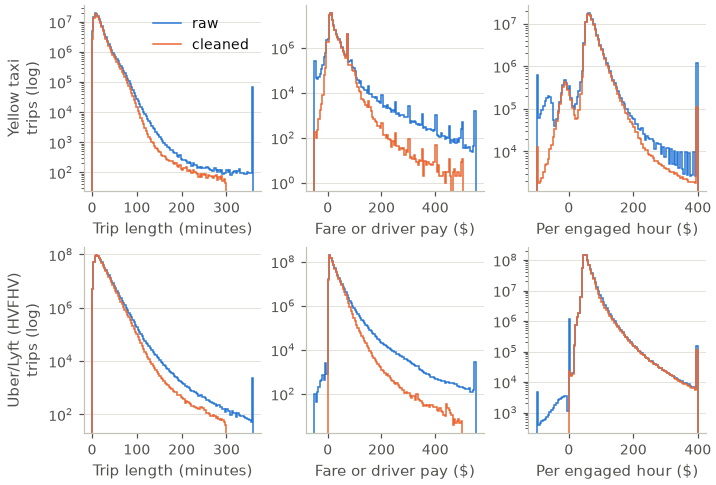

In [26]:
money_labels = {"trip_minutes": "Trip length (minutes)",
                "money": "Fare or driver pay ($)",
                "money_per_hour": "Per engaged hour ($)"}
before_cleaning, after_cleaning = {}, {}
for service in config.SERVICES:
    before_cleaning[service] = explore.histograms(
        explore.add_money_columns(raw[service], service), explore.HIST_SPECS)
    after_cleaning[service] = explore.histograms(
        explore.add_money_columns(trips[service], service),
        explore.HIST_SPECS)

plots.before_after_histograms(before_cleaning, after_cleaning, money_labels)
plt.show()

**What the histograms show:** cleaning cuts the tails and leaves the body alone. The peaks of all six curves are the same before and after.

- **Trip length:** the raw pile in the last bin (6 hours or more) and the flat tail past 5 hours are gone. Below about 100 minutes the two curves sit on top of each other.
- **Fare or driver pay:** raw yellow has a pile of negative fares in the first bin (reversal rows) and one past $550. The negative values left in the cleaned yellow data are the 2025 Flex Fare trips with negative fares (Section 3.3). They are kept as trips, but their revenue is unknown, so they never reach earnings per engaged hour. The yellow bumps near $70 are the JFK flat fare.
- **Per engaged hour:** raw rows have large piles at both ends (under −$100 and over $400 an hour). They come from reversals and from trips a few seconds long, where dividing by the time blows up. Most of them go. The cleaned high volume for-hire vehicle curve still has a small pile at $400 or more an hour, under 0.01% of trips, mostly short trips paid a minimum fare. These are real trips, and every earnings outcome is a median, so they don't move the results.

**For the report (Preprocessing):** the cut-offs are 1 minute to 5 hours, 100 miles, 60 mph and $500 of fare or driver pay. Together they remove under 0.3% of either service (Section 3.7).

### 5.2 Nulls, and what the cleaning removes from each trip group

The null counts are in Section 3.2. As a share of raw rows, by year:

In [27]:
for service in config.SERVICES:
    print(f"{service}: rows with a null (%)")
    display(plots.flat(  # noqa: F821
        explore.null_shares(nulls[service]).round(2)))

yellow: rows with a null (%)


,passenger_count,RatecodeID,congestion_surcharge,airport_fee,cbd_congestion_fee
year,,,,,
2023,3.42,3.42,3.42,3.42,100.0
2024,9.94,9.94,9.94,9.94,100.0
2025,23.83,23.83,23.83,23.83,0.0


fhvhv: rows with a null (%)


,cbd_congestion_fee
year,
2023,100.0
2024,100.0
2025,0.0


Section 3.7 showed that raw yellow rows grew 18% in 2025 against 2% for high volume for-hire vehicle, and that the share removed for `payment_type` 3, 4 and 6 rose from 1.9% to 2.9%. If a rule removed a bigger share of one trip group after the toll than before, the cleaning itself would move the treated-versus-control comparison. The table below counts each raw row once, under the first rule it fails, as a share of that group's raw rows in the year. `unknown_zone` holds trips with an end in zone 264 or 265 that don't touch the CBD or ring, so they have no group.

In [28]:
removals = {s: explore.removals_by_group(raw[s], s, spark, zone_labels)
            for s in config.SERVICES}
for service in config.SERVICES:
    print(f"{service}: share of each group's raw rows removed (%)")
    display(plots.flat(  # noqa: F821
        explore.removal_shares(removals[service]).round(2)))

yellow: share of each group's raw rows removed (%)


trip_group           treated              ring             control         \
year                    2023  2024  2025  2023  2024  2025    2023   2024   
rule                                                                        
charged_trip            1.69  2.35  2.59  1.82  2.26  2.37    3.39   4.56   
distance_cap            0.00  0.00  0.00  0.00  0.00  0.00    0.00   0.01   
dropoff_after_pickup    0.03  0.02  1.12  0.03  0.03  1.43    0.01   0.01   
known_ratecode          0.18  0.44  0.70  0.36  0.86  1.29    3.11   5.34   
known_zones             0.43  0.41  0.31  0.48  0.47  0.35    0.00   0.00   
money_cap               0.00  0.00  0.00  0.00  0.00  0.00    0.00   0.00   
pickup_in_file_month    0.00  0.00  0.00  0.00  0.00  0.00    0.00   0.00   
positive_distance       1.34  1.24  2.35  1.53  1.42  2.21    2.71   2.60   
positive_fare           0.22  0.34  0.38  0.23  0.31  0.34    0.45   0.60   
speed_cap               0.00  0.00  0.01  0.01  0.01  0.01    0.01   0.01   
trip_length             0.21  0.18  0.14  0.25  0.22  0.19    0.84   0.86   
all rules               4.09  4.99  7.59  4.72  5.59  8.20   10.53  14.00   

trip_group                  unknown_zone                  
year                   2025         2023    2024    2025  
rule                                                      
charged_trip           4.49         3.16    5.36    7.45  
distance_cap           0.01         0.05    0.11    0.12  
dropoff_after_pickup   0.84         1.25    1.59    1.60  
known_ratecode         6.63         0.24    1.94    0.19  
known_zones            0.00        83.73   80.87   80.95  
money_cap              0.00         0.02    0.05    0.07  
pickup_in_file_month   0.00         0.01    0.00    0.00  
positive_distance      3.56         9.44    7.38    6.62  
positive_fare          0.62         0.54    0.72    1.00  
speed_cap              0.02         0.08    0.10    0.10  
trip_length            0.83         1.48    1.87    1.92  
all rules             16.99       100.00  100.00  100.00

fhvhv: share of each group's raw rows removed (%)


trip_group           treated              ring             control        \
year                    2023  2024  2025  2023  2024  2025    2023  2024   
rule                                                                       
distance_cap            0.01  0.01  0.01  0.01  0.01  0.01    0.00  0.00   
dropoff_after_pickup    0.01  0.01  0.01  0.00  0.00  0.01    0.00  0.00   
known_zones             4.12  4.17  4.84  2.21  2.18  2.38    0.00  0.00   
money_cap               0.00  0.00  0.00  0.00  0.00  0.00    0.00  0.00   
positive_distance       0.01  0.01  0.01  0.01  0.01  0.01    0.02  0.01   
positive_driver_pay     0.38  0.02  0.03  0.42  0.02  0.02    0.53  0.03   
speed_cap               0.00  0.00  0.00  0.00  0.00  0.00    0.00  0.00   
trip_length             0.00  0.00  0.00  0.00  0.00  0.00    0.01  0.01   
all rules               4.52  4.22  4.90  2.66  2.23  2.43    0.56  0.06   

trip_group                 unknown_zone                  
year                  2025         2023    2024    2025  
rule                                                     
distance_cap          0.00         0.24    0.21    0.20  
dropoff_after_pickup  0.00         0.00    0.01    0.01  
known_zones           0.00        99.70   99.74   99.77  
money_cap             0.00         0.00    0.00    0.00  
positive_distance     0.01         0.00    0.00    0.00  
positive_driver_pay   0.02         0.02    0.03    0.01  
speed_cap             0.00         0.02    0.02    0.01  
trip_length           0.01         0.01    0.00    0.00  
all rules             0.05       100.00  100.00  100.00

**Nulls:** the only nulls in either service are in the four yellow columns Flex Fare trips leave blank. They are 3.4% of yellow rows in 2023, 9.9% in 2024 and 23.8% in 2025. `cbd_congestion_fee` is null before 2025 because the column didn't exist. *Report sentence:* "The only missing values are in four yellow columns that Flex Fare trips (a fixed price agreed upfront) leave blank; these trips grew from 3.4% of yellow rows in 2023 to 23.8% in 2025, so dropping them would make yellow trips look as if they fell after the toll, and we keep them."

**What the cleaning removes, by group:**

- **Yellow:** the rules remove more from control trips than from treated trips in every year: 10.5% → 14.0% → 17.0% of control rows, against 4.1% → 5.0% → 7.6% of treated rows. The gap is mostly `RatecodeID` 99 (5.3% of control rows in 2024) and payment types 3, 4 and 6. But the before/after comparison uses 2024 against 2025, and between those two years the removed share rose by **2.6 points for treated, 2.6 for ring and 3.0 for control**. Uneven cleaning can therefore account for only about 0.4 points of any yellow treated-versus-control gap. Most of the 2025 rise is drop-off ≤ pickup (Section 5.3) and zero distance, which rise by about the same amount in every group.
- **High volume for-hire vehicle:** flat, apart from one rule. The share of treated trips removed because the other end is zone 264 or 265 (unknown or outside NYC) rose from **4.17% in 2024 to 4.84% in 2025**, and for ring trips from 2.18% to 2.38%. By definition no control trip is removed this way. So about **0.7 points of the fall in treated high volume for-hire vehicle trips** could be trips between the CBD and places outside NYC, such as New Jersey, that are growing or being recorded differently, not trips lost to the toll. **Step 6 should note this** next to the treated coefficient.
- The high volume for-hire vehicle driver pay ≤ 0 removals of early 2023 (Section 3.7) show up as 0.4–0.5% in 2023 and 0.02–0.03% afterwards. That is 2023 only, so it doesn't touch the 2024/2025 comparison, but it does mean 2023 counts run about 0.4% low in the event study.

### 5.3 Yellow `VendorID` 7

Yellow rows with a drop-off at or before the pickup jumped from about 1,000 a month to 20,000–70,000 a month from March 2025, just after the toll started (Section 3.7). Almost all of them come from one vendor, `VendorID` 7, which first appears in December 2024. The data dictionary of 18 March 2025 lists vendor 7 as Helix.

In [29]:
vendors = explore.yellow_vendors(raw["yellow"], spark, zone_labels)
vendor_7, vendor_7_groups = explore.vendor_table(vendors, vendor=7, year=2025)
print("Vendor 7 rows, rows with drop-off <= pickup, and share of yellow rows")
display(plots.flat(vendor_7.round(2)))  # noqa: F821
print("Pickup zone group of 2025 rows (%), vendor 7 against all yellow")
plots.flat(vendor_7_groups.round(1))

Vendor 7 rows, rows with drop-off <= pickup, and share of yellow rows


,rows,zero_time,share_of_yellow
file_month,,,
2024-12-01,230,230,0.01
2025-01-01,1206,1206,0.03
2025-02-01,4420,4420,0.12
2025-03-01,21481,21481,0.52
2025-04-01,33844,33844,0.85
2025-05-01,63261,63261,1.38
2025-06-01,67573,67573,1.56
2025-07-01,55438,55438,1.42
2025-08-01,47276,47276,1.32


Pickup zone group of 2025 rows (%), vendor 7 against all yellow


,vendor_7,all_yellow
pickup_group,,
cbd,56.4,56.8
control,24.2,28.1
ring,19.3,14.9
NaN,0.0,0.2


**Vendor 7 explains the jump.** It first appears with 230 rows in December 2024 and grows to 1.3–1.6% of yellow rows a month from May 2025: **535,901 rows in 2025**, 1.1% of that year's raw yellow rows. **Every** one of them has the drop-off time equal to the pickup time, so the drop-off ≤ pickup rule removes all of them. (The data dictionary defines both times as when the meter was engaged and disengaged, so vendor 7 doesn't record the meter times.) The other columns (fares, distances, zones) are filled in, so these are probably real trips.

**Decision: keep the rule.** Without a trip time, trip length, speed and earnings per engaged hour can't be worked out. The removal also can't create a treated-versus-control gap: vendor 7's 2025 pickups split across zone groups much like all yellow pickups (56.4% in the CBD against 56.8%, 24.2% control against 28.1%, 19.3% ring against 14.9%), so it takes about the same share from each group. It does lower the 2025 yellow totals by about 1.1%, which goes in **Limitations**.

### 5.4 Trips touching the CBD compared with the rest of the city (Figure 1)

Each month's treated trips (and ring trips) divided by its control trips, indexed so each service's 2024 average is 100. Seasons, holidays and citywide changes hit every group, so they mostly cancel in the ratio, and a line that falls after the dashed line means that group lost trips compared with the rest of the city. (A first version plotted each group's weekly trips separately; seasons and holiday weeks moved all three lines by up to 40 points, which hid the gap between them.) The table after the figure gives the change in trips for the five fine groups.

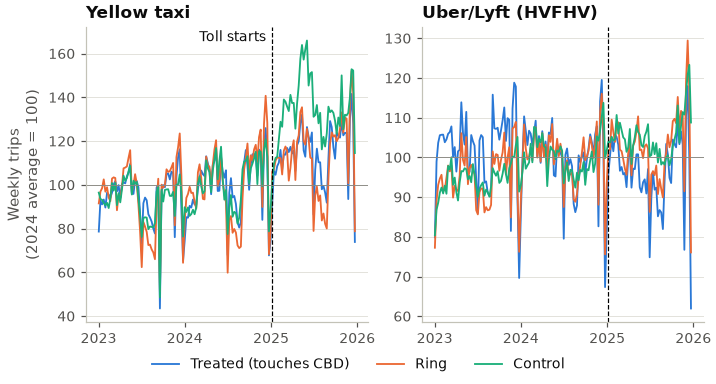

period                    before      after  change_pct
service trip_group                                     
fhvhv   control_far    105828642  111589706         5.4
        control_near    19430947   19633720         1.0
        ring_across     15784341   16208681         2.7
        ring_adjacent    7508326    7519105         0.1
        treated         78688121   75081405        -4.6
yellow  control_far      1983214    3059580        54.3
        control_near     2420342    2813812        16.3
        ring_across       311251     625836       101.1
        ring_adjacent    5024781    5340695         6.3
        treated         28315527   31931640        12.8

In [30]:
relative = explore.relative_trips(summary)
fig = plots.relative_trips(relative, config.TOLL_START_DATE)
plots.save(fig, "fig1_relative_trips")
plt.show()

# Trips in the toll period against the same dates in 2024, by fine group
plots.flat(explore.group_change(summary, "trip_group").round(1))

**From Figure 1 we see** that, relative to control trips, high volume for-hire vehicle trips touching the CBD averaged **91.2** in 2025 against 100 in 2024, while ring trips barely moved (97.3). **So** the toll cost CBD drivers trips and didn't simply move them into the ring. **But** the treated line was already sliding before the toll: it averaged 107.9 in 2023. Part of the 2025 fall may be a trend the toll didn't cause, and the event study in Section 6 (Figure 4) has to test this before the difference-in-differences estimate can be trusted. Yellow treated and ring trips were flat against control before the toll (101.4 and 101.6 in 2023) and fell to about **85** in 2025. They fell together, **probably because** yellow cabs outside Manhattan grew so fast in 2025 (control +33%, the Flex Fare growth of Section 3.8), not because the toll hit the ring as hard as the CBD.

Two more things for Step 6:

- The high volume for-hire vehicle treated ratio bounces back to 97–98 in September and October 2025, then falls to 81 in December. Worth checking in the event study before reading the 2025 average as one steady effect.
- By fine group (table), high volume for-hire vehicle `ring_adjacent` trips were flat (+0.1%) and `ring_across` rose 2.7%, against +5.4% for `control_far`. Both ring halves grew less than the far control zones, so neither shows a clear spillover *gain* at this level. The `control_near` band (+1.0%) also grew much less than `control_far`, which supports running the Step 6 buffer-band check. Yellow `ring_across` doubled (+101%) on a small base (311,251 trips before), in line with Step 4b's warning.

### 5.5 Change by pickup zone (Figure 2)

Pickups and median earnings per engaged hour in each pickup zone, toll period against the same dates in 2024. The medians are taken over every trip in Spark, not over the summary table's cell medians. Zones with **fewer than 10 pickups a day** in the 2024 period are greyed out, because their percentage changes rest on too few trips (at 10 a day, about 3,600 trips in the period, chance alone moves a count by about 2%). The inset zooms in on the CBD and the ring.

Figure 2 in the report is the high volume for-hire vehicle pair; the yellow pair is below it.

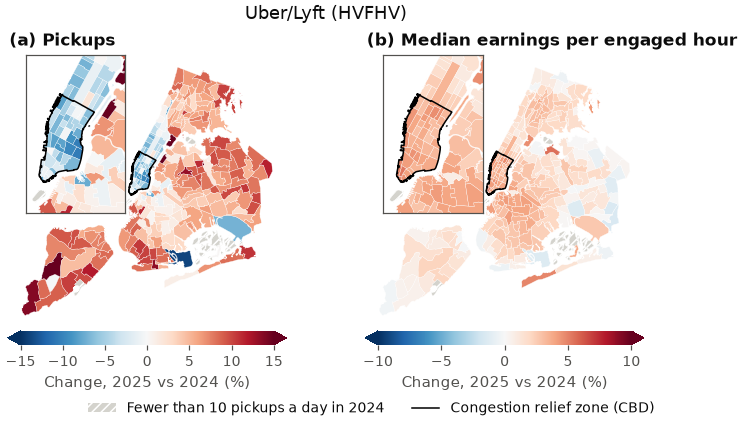

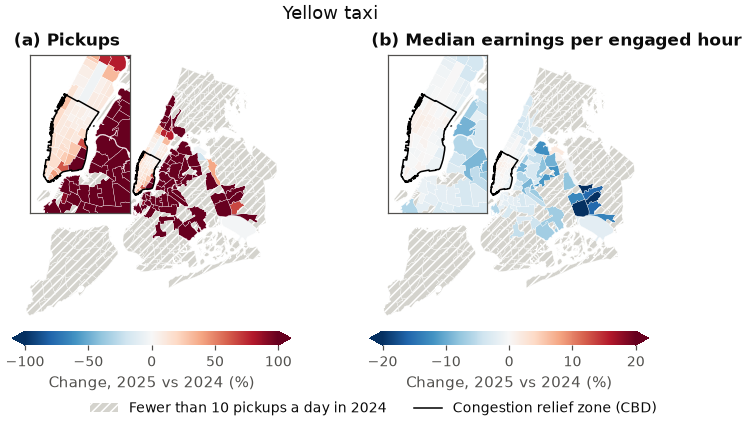

yellow: 110 zones shown


period,change_pct,eph_change_pct
count,110.0,110.0
mean,129.7,-3.3
std,144.8,5.1
min,-19.8,-25.7
25%,10.7,-3.5
50%,66.2,-1.8
75%,224.3,-0.1
max,556.4,2.0


fhvhv: 256 zones shown


period,change_pct,eph_change_pct
count,256.0,256.0
mean,3.4,2.2
std,5.9,1.4
min,-13.8,-1.5
25%,-0.0,1.2
50%,4.6,2.2
75%,7.4,3.2
max,26.3,5.5


In [31]:
zone_medians = {s: explore.zone_medians(trips[s]) for s in config.SERVICES}
zone_changes = {s: explore.zone_change(summary[summary["service"] == s],
                                       zone_medians[s])
                for s in config.SERVICES}
shapes = zones.load_zone_shapes()
too_few = f"Fewer than {explore.MIN_DAILY_PICKUPS} pickups a day in 2024"
map_titles = ["(a) Pickups", "(b) Median earnings per engaged hour"]

# Colour limits (%) for each service's pair, from the ranges below
map_limits = {"fhvhv": [15, 10], "yellow": [100, 20]}
for service in ["fhvhv", "yellow"]:
    fig = plots.zone_maps(shapes, zone_labels, zone_changes[service],
                          ["change_pct", "eph_change_pct"], map_titles,
                          map_limits[service], too_few)
    fig.suptitle(plots.SERVICE_NAMES[service])
    if service == "fhvhv":
        plots.save(fig, "fig2_zone_maps")
    plt.show()

for service in config.SERVICES:
    shown = zone_changes[service][zone_changes[service]["enough_trips"]]
    print(f"{service}: {len(shown)} zones shown")
    display(plots.flat(  # noqa: F821
        shown[["change_pct", "eph_change_pct"]].describe().round(1)
        .rename_axis("statistic")))

In [32]:
# Uber/Lyft zones with the biggest changes in pickups, among zones shown
names = zone_labels.set_index("LocationID")[["Zone", "zone_group_fine"]]
shown = (zone_changes["fhvhv"][zone_changes["fhvhv"]["enough_trips"]]
         .join(names, on="PULocationID")
         [["PULocationID", "Zone", "zone_group_fine", "daily_before",
           "change_pct", "eph_before", "eph_after", "eph_change_pct"]])
print("Biggest falls in pickups")
display(plots.flat(  # noqa: F821
    shown.nsmallest(10, "change_pct").round(1)))
print("Biggest rises in pickups")
display(plots.flat(  # noqa: F821
    shown.nlargest(10, "change_pct").round(1)))

# Median of the zone changes in each fine zone group
plots.flat(shown.groupby("zone_group_fine")
           [["change_pct", "eph_change_pct"]]
           .median().round(1).reindex(clean.ZONE_GROUPS))

Biggest falls in pickups


,PULocationID,Zone,zone_group_fine,daily_before,change_pct,eph_before,eph_after,eph_change_pct
153,154,Marine Park/Floyd Bennett Field,control_far,68.8,-13.8,61.0,60.2,-1.3
3,4,Alphabet City,cbd,2010.9,-10.4,54.3,56.0,3.2
223,224,Stuy Town/Peter Cooper Village,cbd,1421.9,-10.4,53.4,55.5,3.9
78,79,East Village,cbd,8372.7,-9.7,53.8,55.6,3.3
106,107,Gramercy,cbd,4995.8,-8.9,53.1,54.6,2.8
113,114,Greenwich Village South,cbd,4023.0,-8.8,53.2,55.2,3.7
49,50,Clinton West,cbd,3598.1,-8.2,53.2,54.9,3.0
248,249,West Village,cbd,5846.3,-8.1,52.7,54.6,3.5
112,113,Greenwich Village North,cbd,3894.6,-8.1,51.7,53.6,3.6
119,120,Highbridge Park,control_far,64.6,-8.0,58.4,59.8,2.5


Biggest rises in pickups


,PULocationID,Zone,zone_group_fine,daily_before,change_pct,eph_before,eph_after,eph_change_pct
193,194,Randalls Island,control_far,110.1,26.3,98.1,102.6,4.6
192,193,Queensbridge/Ravenswood,ring_across,940.8,18.9,53.1,54.4,2.4
98,99,Freshkills Park,control_far,13.8,18.1,65.9,66.4,0.7
56,57,Corona,control_far,136.3,17.5,59.6,59.9,0.6
43,44,Charleston/Tottenville,control_far,250.2,13.7,70.1,69.8,-0.3
28,29,Brighton Beach,control_far,1203.4,13.3,55.3,55.6,0.6
82,83,Elmhurst/Maspeth,control_far,1426.4,13.1,54.3,54.9,1.1
171,172,New Dorp/Midland Beach,control_far,387.3,11.9,58.8,59.9,1.7
100,101,Glen Oaks,control_far,382.9,11.6,67.5,67.6,0.3
105,106,Gowanus,control_far,1300.6,11.4,52.2,53.8,3.2


,change_pct,eph_change_pct
zone_group_fine,,
cbd,-5.3,3.9
ring_adjacent,-3.8,2.4
ring_across,2.5,3.5
control_near,0.6,2.9
control_far,5.9,1.7


**From Figure 2 we see** that high volume for-hire vehicle pickups fell in almost every CBD zone (median zone −5.3%) and in the Manhattan zones just north of it (`ring_adjacent`, −3.8%), while they grew in most of the outer boroughs (`control_far` +5.9%). The biggest falls among busy zones are all inside the CBD, in the residential south and east: Alphabet City and Stuy Town (−10.4%), the East Village (−9.7%), Gramercy, Greenwich Village and the West Village (−8 to −9%). **So** drivers lost the most rides where trips are short, **probably because** the flat $1.50 fee is a bigger share of a short fare. Median earnings per engaged hour went the other way: **up 3.9% in the median CBD zone, against 1.7% in the far control zones** (panel b). The zones that lost the most trips gained about 3–4% an hour. One likely reason is faster traffic in the CBD, so each engaged hour covers more distance.

Yellow (second pair, notebook only): pickups grew by more than 100% in many outer-borough zones, the Flex Fare growth again, so the yellow trip map mostly shows that change and says little about the toll. Yellow revenue per engaged hour fell slightly in the median zone (−1.8%).

Among busy zones, the biggest rises in high volume for-hire vehicle pickups are Randalls Island (+26%, a park and event venue with few homes) and Queensbridge/Ravenswood (+18.9%), a `ring_across` zone across the East River from Midtown. Queensbridge is a candidate for Step 7's "wait for rides at ring zones such as [zone]", if the model agrees.

### 5.6 Change by time band and day of week (Figure 3)

For each time band and day of week, how much trips touching the CBD changed **compared with control trips**: (1 + treated change) / (1 + control change) − 1. A value of −8 means treated trips ended up 8% lower than if they had changed the way control trips did. It is a raw version of the difference-in-differences estimate in Section 6, with no weather or other controls. The separate treated and control changes are below the figure.

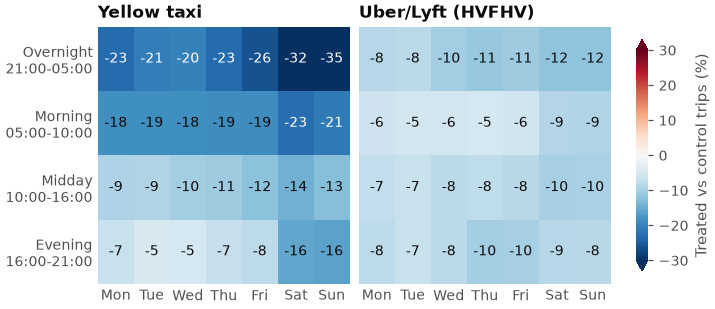

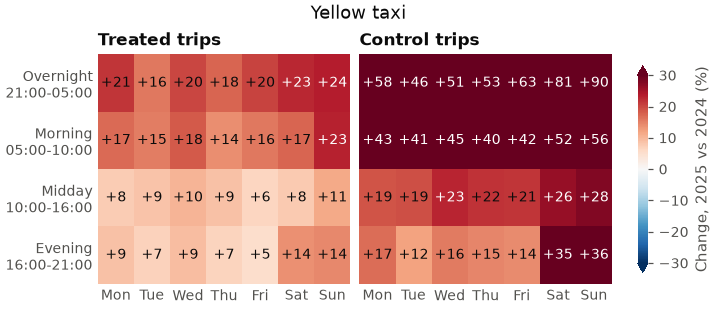

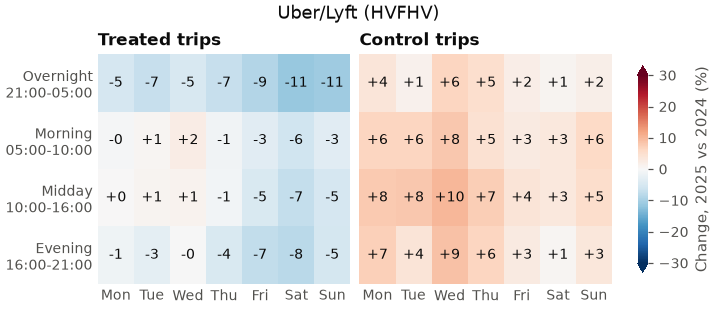

In [33]:
band_day = explore.band_day_change(summary)
fig = plots.band_day_heatmaps(
    [explore.relative_change(band_day, s) for s in config.SERVICES],
    [plots.SERVICE_NAMES[s] for s in config.SERVICES], limit=30,
    label="Treated vs control trips (%)")
plots.save(fig, "fig3_band_day")
plt.show()

for service in config.SERVICES:
    tables = [explore.band_day_table(band_day, service, g)
              for g in ["treated", "control"]]
    fig = plots.band_day_heatmaps(
        tables, ["Treated trips", "Control trips"], limit=30,
        label="Change, 2025 vs 2024 (%)")
    fig.suptitle(plots.SERVICE_NAMES[service])
    plt.show()

**From Figure 3 we see** that high volume for-hire vehicle trips touching the CBD fell against control trips in **every** time band and day, by 5–12%. The gap is widest **overnight (−8 to −12%) and at weekends (−9 to −12% on Saturday and Sunday)**, and smallest on weekday mornings (−5 to −6%). **So** the lost trips are mostly leisure trips rather than commutes, **probably because** those riders have more choice about whether and how to go into the zone, while commuters have to be there. On their own (second figure), weekday morning and midday treated trips hardly changed (−1 to +2%), while weekend and overnight treated trips fell 5–11%.

Yellow shows the same pattern with larger numbers (−5 to −35%, again largest overnight and at weekends), but yellow control trips grew 12–90% depending on the cell (Flex Fare growth), so the yellow gap is mostly control growth, not a treated fall. Yellow treated trips grew in every cell (+5 to +24%).

For Section 6: the time-band model should find the largest effect overnight. If it doesn't, weather or the day-of-week mix is doing more than this raw comparison suggests.

### 5.7 High volume for-hire vehicle pickup wait

The time from a ride request to the pickup (`pickup_datetime` minus `request_datetime`). `on_scene_datetime`, when the driver arrives, would be closer to what we want, but the data dictionary says it is only recorded for accessible vehicles. A longer wait suggests fewer free drivers for the passengers asking; a shorter one, more drivers than passengers.

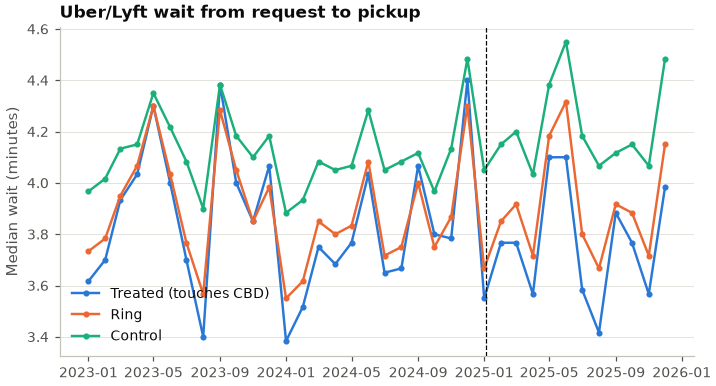

Pickup before request: 6,882,336 trips (1.007%)


median_wait_min               p90_wait_min              
trip_group_coarse         control  ring treated      control  ring treated
year                                                                      
2023                         4.14  3.95    3.92         8.05  8.06    8.24
2024                         4.09  3.84    3.79         7.98  7.81    8.08
2025                         4.20  3.90    3.75         8.58  8.10    7.94

In [36]:
wait = explore.pickup_wait(trips["fhvhv"])
wait_medians = wait.pivot(index="month", columns="trip_group_coarse",
                          values="median_wait_min")[clean.COARSE_TRIP_GROUPS]
plots.monthly_lines(wait_medians, "Median wait (minutes)",
                    "High volume for-hire vehicle wait from request to pickup",
                    config.TOLL_START_DATE)
plt.show()

print(f"Pickup before request: {wait['negative'].sum():,} trips "
      f"({wait['negative'].sum() / wait['trips'].sum():.3%})")
# Average of the monthly medians and 90th percentiles, by year
plots.flat(wait.assign(year=wait["month"].dt.year)
           .groupby(["year", "trip_group_coarse"])
           [["median_wait_min", "p90_wait_min"]]
           .mean().unstack("trip_group_coarse").round(2))

Waits inside the zone got slightly **shorter** relative to the rest of the city. The median wait for treated trips went from 3.79 minutes in 2024 to 3.75 in 2025, while control waits went from 4.09 to 4.20. The 90th percentile tells the same story more strongly: 8.08 → 7.94 minutes for treated trips, 7.98 → 8.58 for control. Shorter waits with fewer trips point to **more free drivers per passenger in the zone** (drivers kept working there as demand fell). So each driver in the CBD may be getting fewer rides per hour online, which earnings per engaged hour can't show, because trip records have no idle time.

About 1.0% of trips (6.9M) have the pickup before the request. They are left out of the waits, and they may be trips booked while the rider was already in the car, or clock differences.

### 5.8 What the exploration found

**What the histograms show:** cleaning cuts the tails and leaves the body alone. The peaks of all six curves are the same before and after.

- **Trip length:** the raw pile in the last bin (6 hours or more) and the flat tail past 5 hours are gone. Below about 100 minutes the two curves sit on top of each other.
- **Fare or driver pay:** raw yellow has a pile of negative fares in the first bin (reversal rows) and one past $550. The negative values left in the cleaned yellow data are the 2025 Flex Fare trips with negative fares (Section 3.3). They are kept as trips, but their revenue is unknown, so they never reach earnings per engaged hour. The yellow bumps near $70 are the JFK flat fare.
- **Per engaged hour:** raw rows have large piles at both ends (under −$100 and over $400 an hour). They come from reversals and from trips a few seconds long, where dividing by the time blows up. Most of them go. The cleaned high volume for-hire vehicle curve still has a small pile at $400 or more an hour, under 0.01% of trips, mostly short trips paid a minimum fare. These are real trips, and every earnings outcome is a median, so they don't move the results.

**For the report (Preprocessing):** the cut-offs are 1 minute to 5 hours, 100 miles, 60 mph and $500 of fare or driver pay. Together they remove under 0.3% of either service (Section 3.7).0

## 6. Models

Model 1: difference-in-differences regression. Model 2: LightGBM forecast of trips without the toll.